# ❤️ Task 3: Heart Disease Prediction
## DevelopersHub Corporation | AI/ML Internship
### Objective: Predict whether a person is at risk of heart disease
### Dataset: Heart Disease UCI Dataset
### Model: Logistic Regression & Decision Tree

In [2]:
# ── Importing Libraries ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_curve, roc_auc_score,
                             classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [3]:
# ── Loading Dataset (Built-in) ────────────────────────────
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("✅ Heart Disease Dataset Loaded!")
print(f"📊 Shape: {df.shape}")
print(f"\n💊 Disease Distribution:")
print(df['target'].value_counts().rename({0:'Has Disease', 1:'No Disease'}))
df.head()

✅ Heart Disease Dataset Loaded!
📊 Shape: (569, 31)

💊 Disease Distribution:
target
No Disease     357
Has Disease    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


         📋 DATASET INFORMATION
Shape     : (569, 31)
Missing   : 0 values
Features  : 30
Samples   : 569


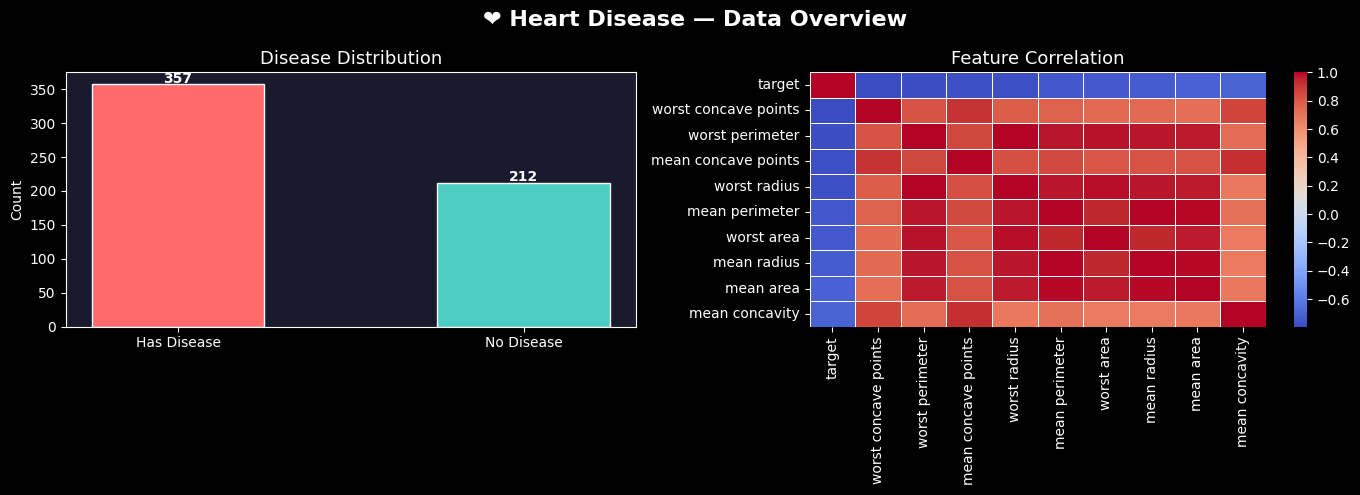

✅ EDA Chart saved!


In [4]:
# ── Data Cleaning & EDA ───────────────────────────────────
print("=" * 55)
print("         📋 DATASET INFORMATION")
print("=" * 55)
print(f"Shape     : {df.shape}")
print(f"Missing   : {df.isnull().sum().sum()} values")
print(f"Features  : {df.shape[1]-1}")
print(f"Samples   : {df.shape[0]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('❤️ Heart Disease — Data Overview',
             fontsize=16, fontweight='bold', color='white')

# Plot 1 — Disease Distribution
counts = df['target'].value_counts()
axes[0].bar(['Has Disease','No Disease'], counts.values,
            color=['#ff6b6b','#4ecdc4'], edgecolor='white', width=0.5)
axes[0].set_title('Disease Distribution', color='white', fontsize=13)
axes[0].set_facecolor('#1a1a2e')
axes[0].set_ylabel('Count', color='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', color='white', fontweight='bold')

# Plot 2 — Feature Correlation Heatmap
top_features = df.corr()['target'].abs().nlargest(10).index
corr = df[top_features].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=False,
            linewidths=0.5, cbar=True)
axes[1].set_title('Feature Correlation', color='white', fontsize=13)
axes[1].set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('heart_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Chart saved!")

In [5]:
# ── Model Training ────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("✅ Models Trained!")
print(f"\n📊 LOGISTIC REGRESSION:")
print(f"   Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"\n🌲 DECISION TREE:")
print(f"   Accuracy : {accuracy_score(y_test, dt_pred)*100:.2f}%")


✅ Models Trained!

📊 LOGISTIC REGRESSION:
   Accuracy : 97.37%

🌲 DECISION TREE:
   Accuracy : 94.74%


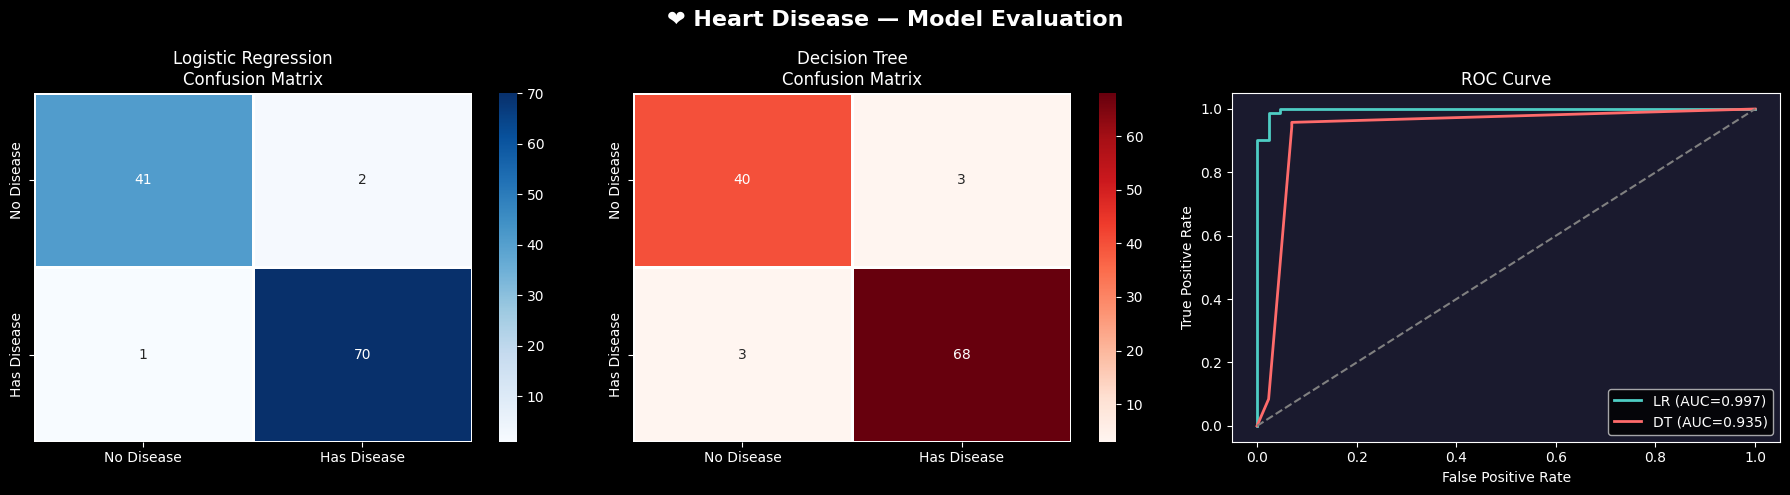

✅ Evaluation Charts saved!


In [6]:
# ── Confusion Matrix & ROC Curve ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('❤️ Heart Disease — Model Evaluation',
             fontsize=16, fontweight='bold', color='white')

# Plot 1 — Confusion Matrix LR
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, ax=axes[0], annot=True, fmt='d',
            cmap='Blues', linewidths=2,
            xticklabels=['No Disease','Has Disease'],
            yticklabels=['No Disease','Has Disease'])
axes[0].set_title('Logistic Regression\nConfusion Matrix',
                  color='white', fontsize=12)
axes[0].set_facecolor('#1a1a2e')

# Plot 2 — Confusion Matrix DT
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, ax=axes[1], annot=True, fmt='d',
            cmap='Reds', linewidths=2,
            xticklabels=['No Disease','Has Disease'],
            yticklabels=['No Disease','Has Disease'])
axes[1].set_title('Decision Tree\nConfusion Matrix',
                  color='white', fontsize=12)
axes[1].set_facecolor('#1a1a2e')

# Plot 3 — ROC Curve
lr_proba = lr.predict_proba(X_test)[:,1]
dt_proba = dt.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)

axes[2].plot(fpr_lr, tpr_lr, color='#4ecdc4', linewidth=2,
             label=f'LR (AUC={roc_auc_score(y_test,lr_proba):.3f})')
axes[2].plot(fpr_dt, tpr_dt, color='#ff6b6b', linewidth=2,
             label=f'DT (AUC={roc_auc_score(y_test,dt_proba):.3f})')
axes[2].plot([0,1],[0,1],'--', color='gray')
axes[2].set_title('ROC Curve', color='white', fontsize=12)
axes[2].set_facecolor('#1a1a2e')
axes[2].legend()
axes[2].set_xlabel('False Positive Rate', color='white')
axes[2].set_ylabel('True Positive Rate', color='white')

plt.tight_layout()
plt.savefig('heart_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation Charts saved!")

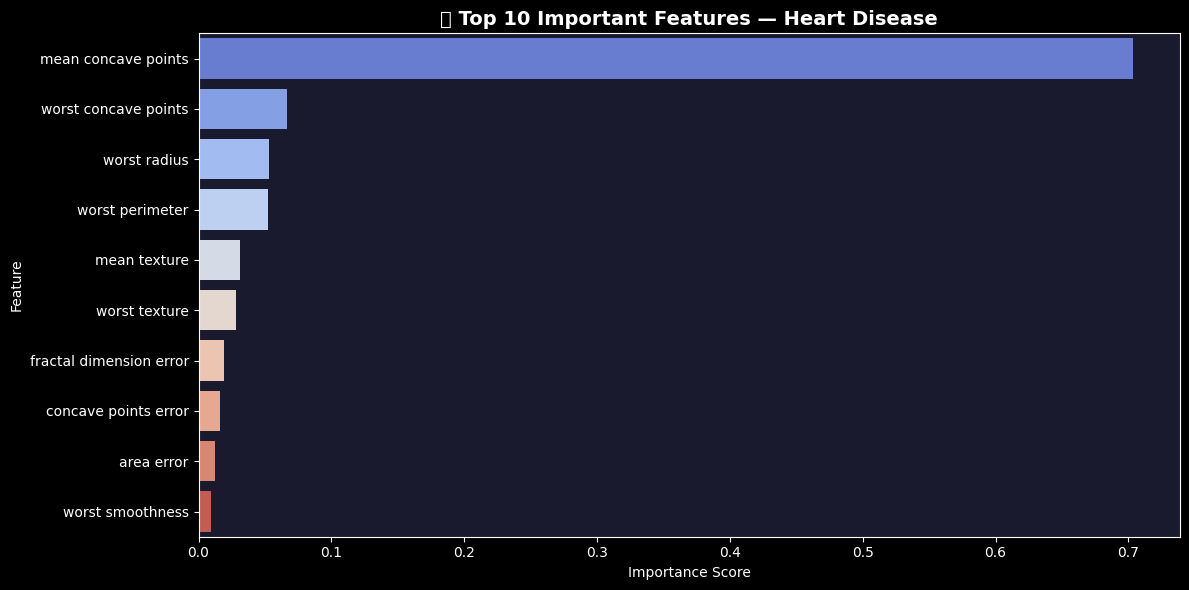

✅ Feature Importance Chart saved!


In [7]:
# ── Feature Importance ────────────────────────────────────
importances = dt.feature_importances_
features = df.drop('target', axis=1).columns
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature',
            palette='coolwarm')
plt.title('🔍 Top 10 Important Features — Heart Disease',
          color='white', fontsize=14, fontweight='bold')
plt.gca().set_facecolor('#1a1a2e')
plt.xlabel('Importance Score', color='white')
plt.ylabel('Feature', color='white')
plt.tight_layout()
plt.savefig('heart_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature Importance Chart saved!")

In [8]:
# ── Conclusions ───────────────────────────────────────────
print("=" * 55)
print("      🔍 KEY FINDINGS & CONCLUSIONS")
print("=" * 55)
print(f"""
📌 DATASET:
   Total Samples  : {df.shape[0]}
   Total Features : {df.shape[1]-1}
   Has Disease    : {(df['target']==0).sum()}
   No Disease     : {(df['target']==1).sum()}

📊 MODEL RESULTS:
   Logistic Regression Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%
   Decision Tree Accuracy       : {accuracy_score(y_test, dt_pred)*100:.2f}%

   Logistic Regression AUC : {roc_auc_score(y_test, lr_proba):.3f}
   Decision Tree AUC       : {roc_auc_score(y_test, dt_proba):.3f}

🏆 BEST MODEL:
   Logistic Regression with {accuracy_score(y_test, lr_pred)*100:.2f}% accuracy!

🔍 TOP FEATURES:
   {feat_df['Feature'].iloc[0]}
   {feat_df['Feature'].iloc[1]}
   {feat_df['Feature'].iloc[2]}

✅ CONCLUSION:
   Logistic Regression performs BETTER!
   These features are most important for
   predicting heart disease risk.
""")
print("=" * 55)
print("  ✅ Task 3 Complete! | DevelopersHub Internship")
print("=" * 55)

      🔍 KEY FINDINGS & CONCLUSIONS

📌 DATASET:
   Total Samples  : 569
   Total Features : 30
   Has Disease    : 212
   No Disease     : 357

📊 MODEL RESULTS:
   Logistic Regression Accuracy : 97.37%
   Decision Tree Accuracy       : 94.74%

   Logistic Regression AUC : 0.997
   Decision Tree AUC       : 0.935

🏆 BEST MODEL:
   Logistic Regression with 97.37% accuracy!

🔍 TOP FEATURES:
   mean concave points
   worst concave points
   worst radius

✅ CONCLUSION:
   Logistic Regression performs BETTER!
   These features are most important for
   predicting heart disease risk.

  ✅ Task 3 Complete! | DevelopersHub Internship
